## Multiple Linear Regression

In [1]:
from sklearn.datasets import fetch_california_housing

### Step 0 :- Import Required Libarays 

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
data = fetch_california_housing()
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [4]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [5]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [4]:
data.target_names

['MedHouseVal']

In [5]:
# Datapoints
print(data.data)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


In [6]:
# Price of House
print(data.target)

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [9]:
# Columns Name
data.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

### Stpe 1 : Load the Data/ Create DataFrame

In [7]:
# Create dataframe 

df = pd.DataFrame(data.data,columns=data.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [8]:
# Adding Price column into dataframe
df["Price"] = data.target

In [9]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#### Overview of data

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [11]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [12]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Step 2 :- Data Preprocessing / EDA

In [13]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


<Axes: >

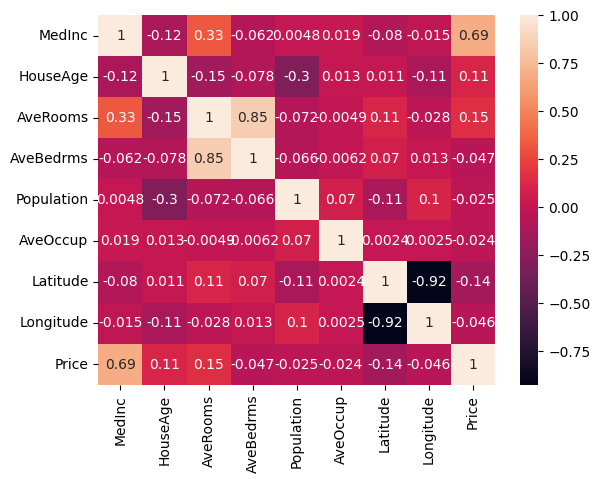

In [14]:
sns.heatmap(df.corr(),annot=True)

The graph you've shared is a **heatmap** representing the **correlation matrix** between various features in a dataset. Here's how to interpret it:

### Key Observations:
- **Diagonal values**: The diagonal of the heatmap shows values of **1** because each feature is perfectly correlated with itself.
- **Colors**: The color intensity represents the strength of the correlation, with lighter shades indicating stronger positive correlations and darker shades indicating negative correlations.
- **Correlations**: Correlation values range from -1 to 1:
  - **+1** indicates a perfect positive correlation (i.e., when one variable increases, the other also increases).
  - **-1** indicates a perfect negative correlation (i.e., when one variable increases, the other decreases).
  - **0** indicates no correlation between the variables.

### Interpretation of Key Features:
1. **MedInc vs. Price**:
   - **Correlation: 0.69**: There is a strong positive correlation between the **MedInc** (median income) and **Price**. As the median income increases, the price tends to increase as well.

2. **AveRooms vs. AveBedrms**:
   - **Correlation: 0.85**: There is a strong positive correlation between the **AveRooms** (average number of rooms) and **AveBedrms** (average number of bedrooms). More rooms tend to correlate with more bedrooms.

3. **Longitude vs. Latitude**:
   - **Correlation: -0.92**: There is a strong negative correlation between **Longitude** and **Latitude**. This suggests that as you move east or west (longitude), there is a strong tendency for the latitude to decrease (potentially pointing to a geographic region with a particular location pattern, e.g., west coast to east coast).

4. **Longitude vs. Latitude (strong negative correlation)**:
   - **Correlation: -0.92**: There is a very strong negative correlation between **Longitude** and **Latitude**. This could indicate that for the dataset's locations, a change in longitude is often associated with an inverse change in latitude.

5. **Population and AveOccup**:
   - **Correlation: 0.07**: There is a very weak positive correlation between **Population** and **AveOccup** (average number of occupants per household). A slight positive relationship, meaning higher population might have a tiny increase in the average number of occupants.

6. **Price**:
   - The **Price** feature has a moderate positive correlation with **MedInc** and weaker correlations with other features like **AveRooms** and **AveBedrms**. This suggests that the house price tends to increase with higher median income and slightly with the number of rooms and bedrooms.


### Step 3 :- Divide Our Dataset into independent and dependent features

In [15]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [16]:
# X = df.iloc[:,:-1]  #independent feature
# y = df.iloc[:,-1]  #dependent feature

In [17]:
X = df.drop(columns= 'Price')
y = df['Price']

In [18]:
X.shape , y.shape

((20640, 8), (20640,))

In [19]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


### Step 4:- Split Data into Trian and Test data

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.33,random_state=10)

In [22]:
X_train.shape , X_test.shape

((13828, 8), (6812, 8))

In [23]:
y_train.shape , y_test.shape

((13828,), (6812,))

### Step 5:- Standardize the dataset Train Independent data

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
Scalar = StandardScaler() 

In [26]:
X_train = Scalar.fit_transform(X_train)

In [27]:
X_test = Scalar.transform(X_test)

In [28]:
X_train

array([[-0.72986836,  1.22081889, -0.70305988, ...,  0.05861244,
         0.96929441, -1.43979718],
       [-0.61046678, -0.28439808,  0.07828001, ...,  0.13015917,
        -0.75823526,  1.08204942],
       [ 0.00784578, -0.60128586, -0.2447376 , ..., -0.09793279,
         0.94594941, -1.2454256 ],
       ...,
       [ 0.88684913, -1.78961504, -0.21300658, ...,  0.09549475,
         0.78720344, -1.10587678],
       [-0.87672223,  0.50782138, -1.10043274, ...,  0.18513096,
        -0.77224225,  0.66838683],
       [-0.62742573, -0.99739558, -0.60483749, ..., -0.08418874,
         0.77786545, -1.15073176]])

In [29]:
X_test

array([[ 0.75154854, -1.31428337, -0.39376169, ...,  0.12606697,
        -0.68820027,  0.19491761],
       [ 0.05935857, -0.12595418, -0.33070668, ..., -0.12021013,
         0.89459042, -1.36503888],
       [ 0.34405687, -1.31428337, -0.41007104, ..., -0.15581759,
        -0.91698123,  0.89764561],
       ...,
       [ 0.36483158,  0.27015554,  0.04216837, ..., -0.08014641,
        -0.46875731, -0.43803598],
       [-0.90412152, -0.91817364,  0.66736933, ..., -0.10263685,
         2.51006411, -1.96808915],
       [-0.43377577,  1.22081889, -0.44835491, ...,  0.2807072 ,
        -0.74422826,  0.69330627]])

### Step 6:- Model Buliding and Model Training

In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
Regression = LinearRegression()

In [33]:
Regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
# Slop
Regression.coef_

array([ 0.82872299,  0.1231163 , -0.27068752,  0.32859106,  0.00213572,
       -0.02810091, -0.93017985, -0.89505497])

In [35]:
# Intercepts
Regression.intercept_

2.0634768086491184

### Step :- 7 Prediction for the test data

In [36]:
y_pred = Regression.predict(X_test)

In [37]:
y_pred

array([3.00397485, 2.58011486, 2.3489077 , ..., 3.09003708, 0.79152007,
       2.04477012])

### Step :- 8 Evaluate

In [38]:
from sklearn.metrics import mean_squared_error , mean_absolute_error

In [39]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)

In [40]:
print(f"Mean Square Error   :- {mse}")
print(f"Mean Absolute Error :- {mae}")
print(f"RMSE                :- {rmse}")

Mean Square Error   :- 0.552233239936362
Mean Absolute Error :- 0.5371056943007961
RMSE                :- 0.743123973463622


In [41]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
score

0.5935958526436639

In [42]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.5931179409607519

## Assumptions

Text(0, 0.5, 'Test Predicted Data')

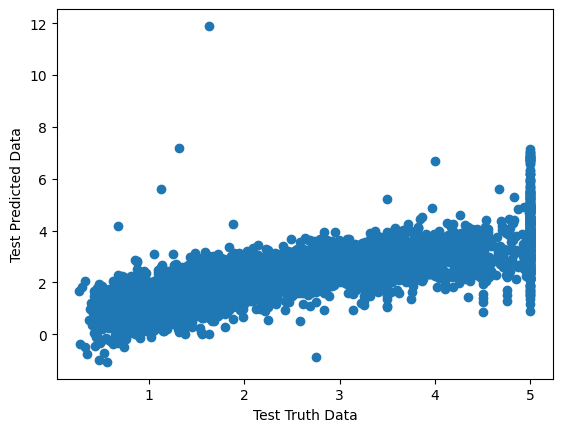

In [43]:
## plot a scatter plot for the prediction
# We say that our model is functioning well if our plot is sort of linear.
plt.scatter(y_test,y_pred)
plt.xlabel("Test Truth Data")
plt.ylabel("Test Predicted Data")

In [44]:
# Residuals

residule = y_test - y_pred
residule

20303   -1.329975
16966    0.960885
10623   -0.746908
6146    -0.307462
2208    -0.662167
           ...   
13490   -0.243475
9340     0.507182
17439   -1.366037
2602     0.046480
7180    -0.627770
Name: Price, Length: 6812, dtype: float64

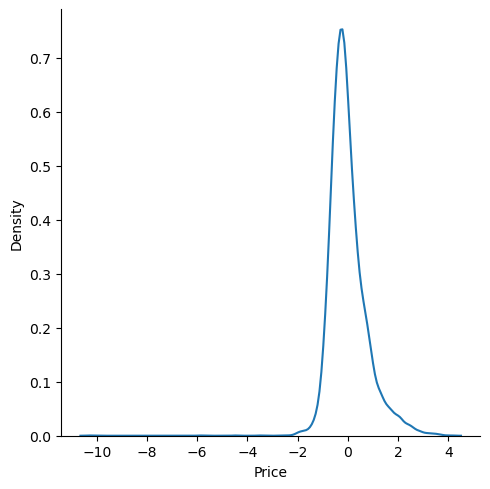

In [56]:
# Plot this Residuals
# Its should look like "Normal Distributions"

import seaborn as sns
sns.displot(residule,kind="kde")
plt.show()

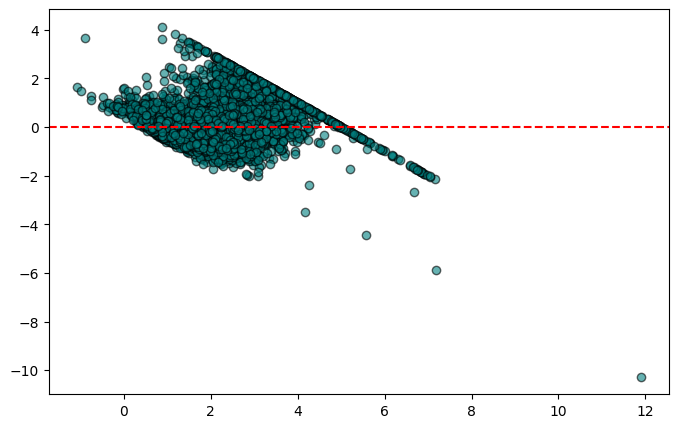

In [45]:
# Scatter plot with respect to prediction and residuals
# its should look like "Uniform distribution"
# Residual = Actual - Predicted
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6, color='teal', edgecolor='k')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)

plt.show()

### Pickling
- Pickling in machine learning refers to the process of serializing a trained model into a byte stream, allowing it to be saved to a file or transferred. This is useful for persisting machine learning models so they can be loaded later for prediction or evaluation without retraining. Pickling avoids the need for repetitive training, saving computational time. However, it may have security risks, especially with untrusted sources, and can be dependent on the Python version and libraries used

In [47]:
import pickle

In [48]:
# Save the trained model to a file using pickle

pickle.dump(Regression,open('Regression.pkl','wb'))

In [50]:
# Load the saved model from the file

model = pickle.load(open('Regression.pkl','rb'))

In [51]:
# Use the loaded model to make predictions
predictions = model.predict(X_test)
print(predictions)

[3.00397485 2.58011486 2.3489077  ... 3.09003708 0.79152007 2.04477012]
